# **Install libraries & setup environment**

In [ ]:
# Step 1: Install Python 3.8 in Colab
!sudo apt-get update -y
!sudo apt-get install python3.8 python3.8-venv python3.8-dev -y

# Step 2: Create a virtual environment
!python3.8 -m venv tierpsy_env

# Step 3: Activate the environment and install dependencies
!source tierpsy_env/bin/activate && pip install --upgrade pip setuptools wheel
!source tierpsy_env/bin/activate && pip install tables h5py opencv-python-headless tqdm scikit-image scikit-learn matplotlib seaborn pandas

# Step 4: Clone and install Tierpsy
!git clone https://github.com/ver228/tierpsy-tracker.git
!cd tierpsy-tracker && source ../tierpsy_env/bin/activate && pip install -e .

# Step 5: Test
!source tierpsy_env/bin/activate && python -m tierpsy



# **Upload your worm video**

In [15]:
from google.colab import files
uploaded = files.upload()


Saving Worm1.mp4 to Worm1 (1).mp4


# **Count Worms (basic frame-by-frame detection)**

In [16]:
import cv2
import numpy as np
from tqdm import tqdm

# Parameters
min_area = 50
max_area = 1000

# Get the video path from the uploaded files
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
worm_counts = []

for _ in tqdm(range(frame_count), desc="Counting worms"):
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    worm_counts.append(len(contours))

cap.release()

print(f"Approximate average worm count: {int(np.mean(worm_counts))}")
print(f"Maximum detected in a single frame: {max(worm_counts)}")

Counting worms: 100%|██████████| 6670/6670 [05:39<00:00, 19.64it/s]

Approximate average worm count: 3
Maximum detected in a single frame: 9


# **Initial Visualize Worms with Overlay Video**

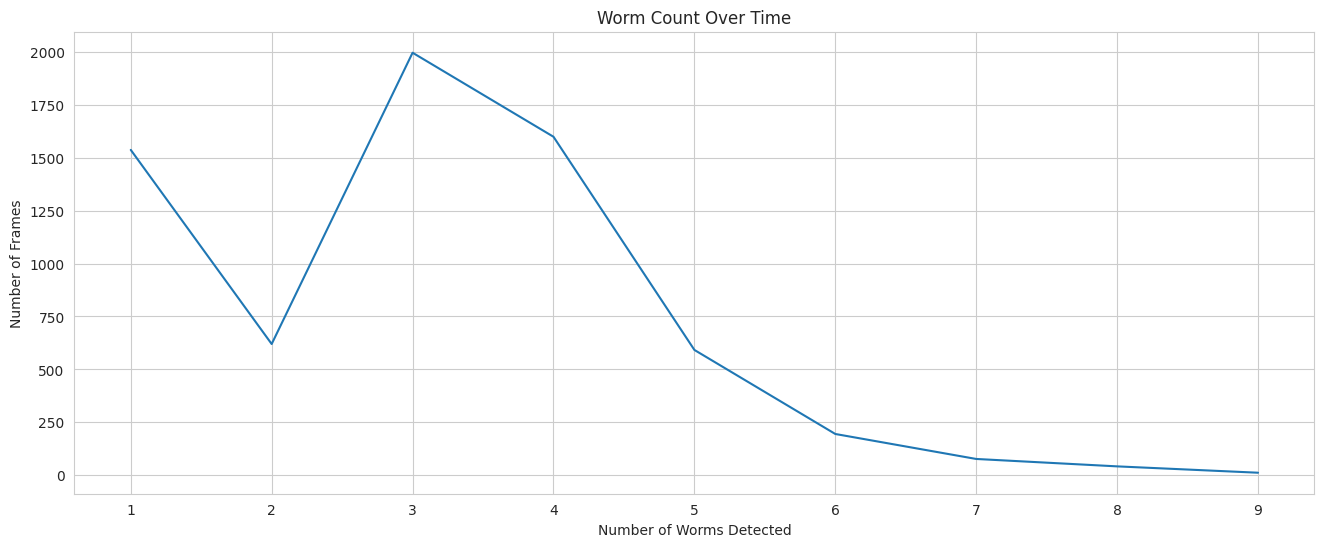

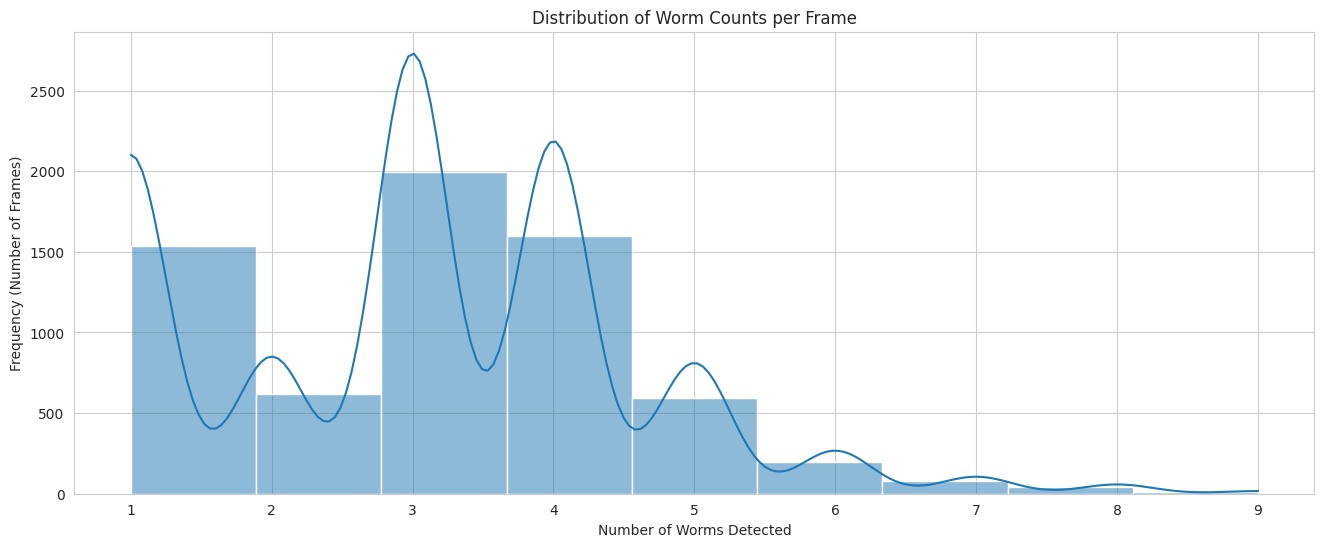


Approximate average worm count: 3.04
Maximum worms detected in a single frame: 9


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_style("whitegrid")

# Create a frequency distribution of worm counts from the worm_counts list
worm_count_distribution = Counter(worm_counts)

# Sort the keys (worm counts) to ensure the plot is ordered correctly
sorted_worm_counts = sorted(worm_count_distribution.keys())
sorted_frequencies = [worm_count_distribution[count] for count in sorted_worm_counts]


# Line plot: Worm count over time
plt.figure(figsize=(16,6))
# Use sorted_worm_counts as x and sorted_frequencies as y for the line plot
sns.lineplot(x=sorted_worm_counts, y=sorted_frequencies)
plt.title("Worm Count Over Time")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Number of Frames")
plt.show()

# Histogram: Distribution of worm counts
plt.figure(figsize=(16,6))
# Use the worm_counts list directly for the histogram as histplot can handle lists
sns.histplot(worm_counts, kde=True, bins=max(1, max(worm_counts) if worm_counts else 1))
plt.title("Distribution of Worm Counts per Frame")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Frequency (Number of Frames)")
plt.show()

# Summary statistics
average_worms = np.mean(worm_counts) if worm_counts else 0
max_worms = max(worm_counts) if worm_counts else 0
print(f"\nApproximate average worm count: {average_worms:.2f}")
print(f"Maximum worms detected in a single frame: {max_worms}")

# **Worm Tracking Using Distance-based Tracking**

Tracking worms: 100%|██████████| 6670/6670 [2:37:45<00:00,  1.42s/it]


✅ Visualization video saved as 'worm_tracking_output.mp4'
Approximate average moving worm count: 402.81
Maximum moving worms detected in a single frame: 1458
✅ Worm counts saved as CSV: 'worm_counts_per_frame.csv'


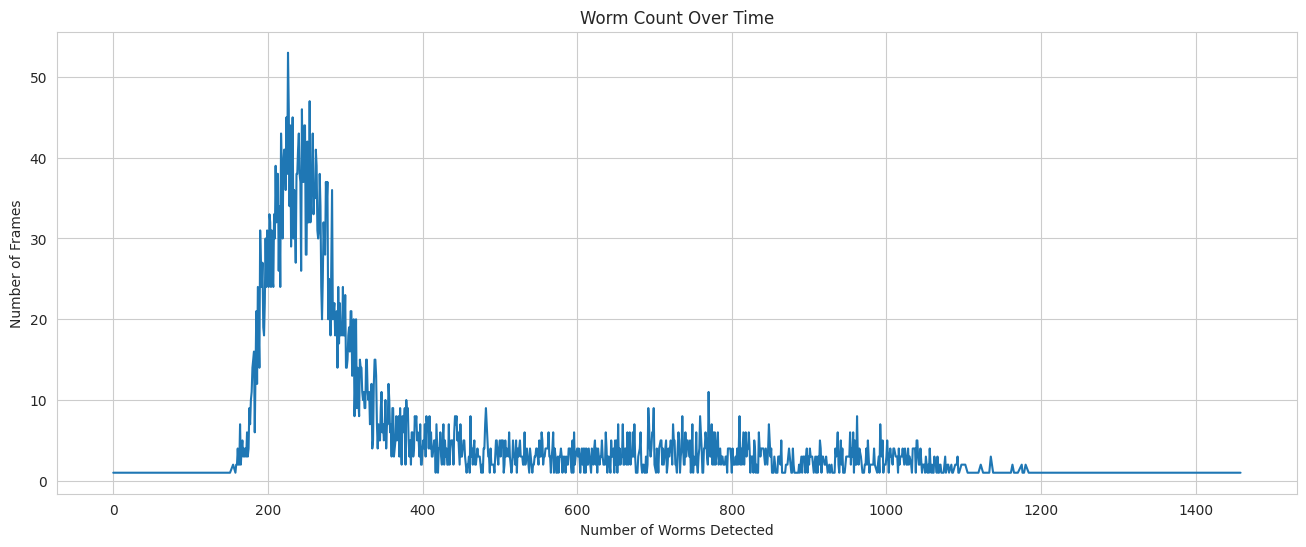

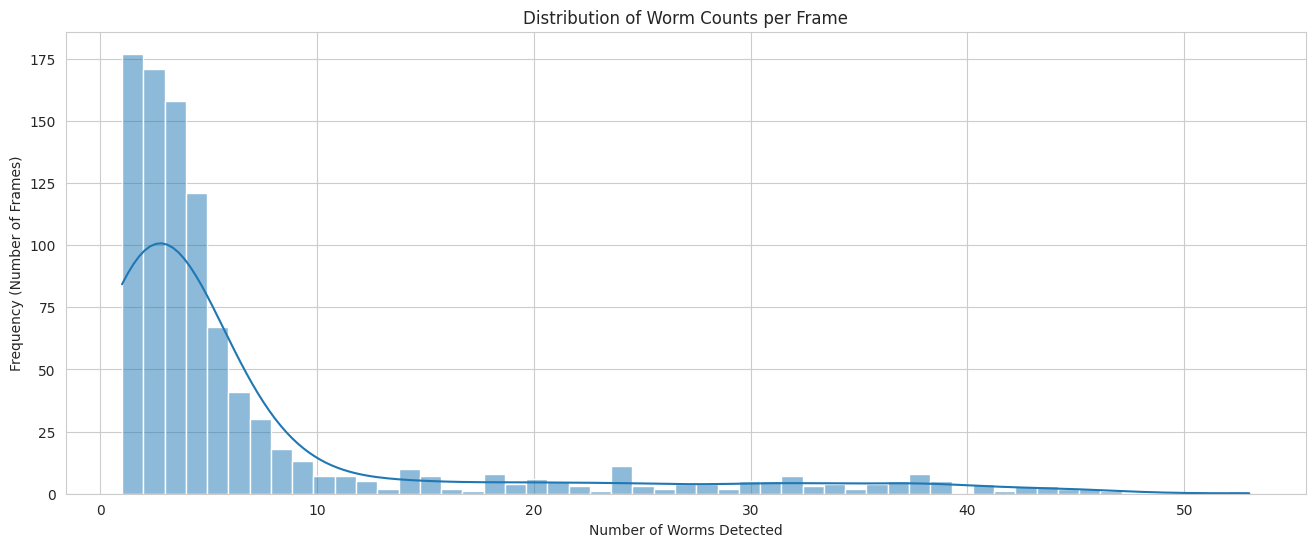

✅ Worm count statistics saved as 'worm_count_stats.jpeg'


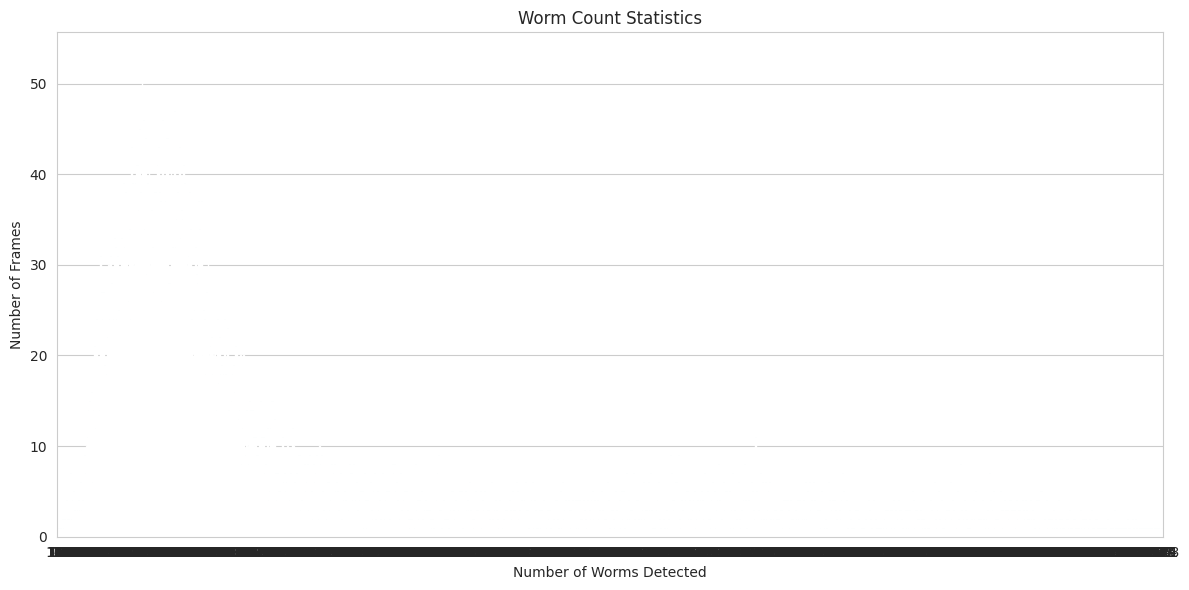

In [19]:
# ==============================
# Worm Counting & Tracking Script
# Using OpenCV on Colab
# ==============================

import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- Adjustable Parameters ----
min_area = 50           # smallest worm contour area (tune for small worms)
max_area = 1000         # largest worm contour area (tune to skip big noise)
distance_threshold = 30 # max pixel distance for tracking worms between frames

# ---- Load Video ----
# Use the video path from the previously uploaded file
video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ---- Background Subtractor ----
fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=40, detectShadows=False)

# ---- Tracking memory ----
next_id = 0
tracks = {}
frame_ids = defaultdict(int)

# ---- Output Video ----
out = cv2.VideoWriter('worm_tracking_output.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# ---- Process frames ----
for i in tqdm(range(frame_count), desc="Tracking worms"):
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)  # enhance contrast
    fgmask = fgbg.apply(gray)
    fgmask = cv2.medianBlur(fgmask, 5)
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)))
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))

    # ---- Contour detection ----
    contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = w / float(h)
            if 0.2 < aspect_ratio < 5:  # filter non-worm shapes
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    cx = int(M["m10"]/M["m00"])
                    cy = int(M["m01"]/M["m00"])
                    detections.append((cx, cy))
                    cv2.circle(frame, (cx, cy), 5, (0,0,255), -1)

    # ---- Distance-based tracking ----
    updated_tracks = {}
    for det in detections:
        x, y = det
        assigned = False
        for tid, (px, py) in tracks.items():
            if np.linalg.norm(np.array([x,y])-np.array([px,py])) < distance_threshold:
                updated_tracks[tid] = (x, y)
                assigned = True
                break
        if not assigned:
            updated_tracks[next_id] = (x, y)
            next_id += 1

    tracks = updated_tracks
    frame_ids[len(tracks)] += 1

    # ---- Overlay worm count ----
    cv2.putText(frame, f"Worms detected: {len(tracks)}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ Visualization video saved as 'worm_tracking_output.mp4'")

# ---- Statistics ----
average_worms = np.average(list(frame_ids.keys()), weights=list(frame_ids.values()))
max_worms = max(frame_ids.keys())
print(f"Approximate average moving worm count: {average_worms:.2f}")
print(f"Maximum moving worms detected in a single frame: {max_worms}")

# ---- Save CSV ----
df = pd.DataFrame({'worms_detected': list(frame_ids.keys()), 'frame_count': list(frame_ids.values())})
df.to_csv("worm_counts_per_frame.csv", index=False)
print("✅ Worm counts saved as CSV: 'worm_counts_per_frame.csv'")

# ---- Plots ----
sns.set_style("whitegrid")

plt.figure(figsize=(16,6))
sns.lineplot(x=list(frame_ids.keys()), y=list(frame_ids.values()))
plt.title("Worm Count Over Time")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Number of Frames")
plt.show()

plt.figure(figsize=(16,6))
sns.histplot(list(frame_ids.values()), kde=True, bins=max(1, max(frame_ids.values())))
plt.title("Distribution of Worm Counts per Frame")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Frequency (Number of Frames)")
plt.show()

# ---- Save statistics as JPEG ----
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=list(frame_ids.keys()), y=list(frame_ids.values()), color='skyblue', ax=ax)
ax.set_title("Worm Count Statistics")
ax.set_xlabel("Number of Worms Detected")
ax.set_ylabel("Number of Frames")
plt.tight_layout()
plt.savefig("worm_count_stats.jpeg")
print("✅ Worm count statistics saved as 'worm_count_stats.jpeg'")

# **Kalman filter tracking, Hungarian assignment for frame-to-track matching, and trajectory smoothing with Savitzky-Golay filter**

In [ ]:
# ===============================
# Improved Worm Tracking Pipeline
# ===============================

import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.signal import savgol_filter

sns.set_style("whitegrid")

# ---- Adjustable Parameters ----
min_area = 50          # smallest worm contour area
max_area = 1000        # largest worm contour area
distance_threshold = 30  # max distance for frame-to-frame assignment
kalman_q = 1e-2        # process noise for Kalman filter
kalman_r = 1e-1        # measurement noise
window_length = 5      # smoothing window (must be odd)
polyorder = 2          # smoothing polynomial order

# ---- Video Input ----
video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ---- Background Subtractor ----
fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=40, detectShadows=False)

# ---- Track Storage ----
next_id = 0
tracks = {}            # active tracks: track_id -> [x, y]
tracks_history = {}    # track_id -> list of positions per frame
frame_ids = defaultdict(int)

# ---- Output Video ----
out = cv2.VideoWriter('worm_tracking_output.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# ---- Initialize Kalman Filters ----
kalman_filters = {}    # track_id -> cv2.KalmanFilter object

def create_kalman_filter(x, y):
    kf = cv2.KalmanFilter(4,2)
    kf.measurementMatrix = np.array([[1,0,0,0],[0,1,0,0]], np.float32)
    kf.transitionMatrix = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], np.float32)
    kf.processNoiseCov = kalman_q * np.eye(4, dtype=np.float32)
    kf.measurementNoiseCov = kalman_r * np.eye(2, dtype=np.float32)
    kf.statePre = np.array([[x],[y],[0],[0]], np.float32)
    return kf

# ---- Main Tracking Loop ----
for i in tqdm(range(frame_count), desc="Tracking worms"):
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    fgmask = fgbg.apply(gray)
    fgmask = cv2.medianBlur(fgmask, 5)
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)))
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))

    # ---- Contour Detection ----
    contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = w / float(h)
            if 0.2 < aspect_ratio < 5:
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    cx = int(M["m10"]/M["m00"])
                    cy = int(M["m01"]/M["m00"])
                    detections.append((cx, cy))

    # ---- Kalman Prediction ----
    predicted_positions = {}
    for tid, kf in kalman_filters.items():
        pred = kf.predict()
        predicted_positions[tid] = (pred[0,0], pred[1,0])

    # ---- Hungarian Assignment ----
    if tracks and detections:
        cost_matrix = np.zeros((len(tracks), len(detections)))
        track_ids = list(tracks.keys())
        for t_idx, tid in enumerate(track_ids):
            tx, ty = predicted_positions[tid]
            for d_idx, (dx, dy) in enumerate(detections):
                cost_matrix[t_idx, d_idx] = np.linalg.norm([tx-dx, ty-dy])
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        assigned_tracks = {}
        assigned_detections = set()
        for r, c in zip(row_ind, col_ind):
            if cost_matrix[r,c] < distance_threshold:
                tid = track_ids[r]
                dx, dy = detections[c]
                # Update Kalman Filter
                measurement = np.array([[np.float32(dx)], [np.float32(dy)]])
                kalman_filters[tid].correct(measurement)
                assigned_tracks[tid] = (dx, dy)
                assigned_detections.add(c)
        # Add unassigned detections as new tracks
        for idx, (dx, dy) in enumerate(detections):
            if idx not in assigned_detections:
                assigned_tracks[next_id] = (dx, dy)
                kalman_filters[next_id] = create_kalman_filter(dx, dy)
                next_id += 1
        tracks = assigned_tracks
    else:
        for dx, dy in detections:
            tracks[next_id] = (dx, dy)
            kalman_filters[next_id] = create_kalman_filter(dx, dy)
            next_id += 1

    # ---- Update track history ----
    for tid, pos in tracks.items():
        if tid not in tracks_history:
            tracks_history[tid] = []
        tracks_history[tid].append(pos)

    frame_ids[len(tracks)] += 1

    # ---- Overlay visualization ----
    for tid, (x, y) in tracks.items():
        cv2.circle(frame, (int(x), int(y)), 5, (0,0,255), -1)
        cv2.putText(frame, str(tid), (int(x)+5,int(y)-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0),1)
    cv2.putText(frame, f"Worms: {len(tracks)}", (20,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

# ===============================
# Trajectory Smoothing
# ===============================
smoothed_tracks = {}
for tid, positions in tracks_history.items():
    if len(positions) >= window_length:
        positions_array = np.array(positions)
        x_smooth = savgol_filter(positions_array[:,0], window_length, polyorder)
        y_smooth = savgol_filter(positions_array[:,1], window_length, polyorder)
        smoothed_tracks[tid] = list(zip(x_smooth, y_smooth))
    else:
        smoothed_tracks[tid] = positions

print("✅ Trajectories smoothed using Savitzky-Golay filter")

# ===============================
# Statistics & Plots
# ===============================
average_worms = np.average(list(frame_ids.keys()), weights=list(frame_ids.values()))
max_worms = max(frame_ids.keys())
print(f"Approximate average moving worm count: {average_worms:.2f}")
print(f"Maximum moving worms detected in a single frame: {max_worms}")

plt.figure(figsize=(16,6))
sns.lineplot(x=list(frame_ids.keys()), y=list(frame_ids.values()))
plt.title("Worm Count Over Time")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Number of Frames")
plt.show()

plt.figure(figsize=(16,6))
sns.histplot(list(frame_ids.values()), kde=True, bins=max(1, max(frame_ids.values())))
plt.title("Distribution of Worm Counts per Frame")
plt.xlabel("Number of Worms Detected")
plt.ylabel("Frequency (Number of Frames)")
plt.show()

# ===============================
# Save Statistics Plot
# ===============================
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=list(frame_ids.keys()), y=list(frame_ids.values()), color='skyblue', ax=ax)
ax.set_title("Worm Count Statistics")
ax.set_xlabel("Number of Worms Detected")
ax.set_ylabel("Number of Frames")
plt.tight_layout()
plt.savefig("worm_count_stats.jpeg")
print("✅ Worm count statistics saved as 'worm_count_stats.jpeg'")


Tracking worms:  29%|██▊       | 1909/6670 [2:49:32<10:24:26,  7.87s/it]